In [2]:
%load_ext autoreload
%autoreload 2

from paper_utils import *

This is for 6 generations (not 8)

In [3]:
runs = {
    'ooslwgb9': '70b-squad-lax-deberta',
    'iuh4ny1v': '70b-squad-strict-deberta',
    'fbtvpw1y': '70b-squad-lax-llama',
    'h5vd2k6a': '70b-squad-strict-llama',
    'rzj7w9ei': '70b-squad-lax-gpt4',
    'e0z3555u': '70b-squad-strict-gpt4',
    # 
    'au7s3uxg': '70b-trivia_qa-lax-deberta',
    'a0x5b6bc': '70b-trivia_qa-strict-deberta',
    '0arsdrk9': '70b-trivia_qa-lax-llama',
    '4g1egsbm': '70b-trivia_qa-strict-llama',
    '91auvvo2': '70b-trivia_qa-lax-gpt4',
    'oxk8fe6o': '70b-trivia_qa-strict-gpt4',
    #
    'e5ptgcwr': '70b-bioasq-lax-deberta',
    '4cceyw6c': '70b-bioasq-strict-deberta',
    'lu4uikdt': '70b-bioasq-lax-llama',
    'o7xsfdju': '70b-bioasq-strict-llama',
    'dn62rrv2': '70b-bioasq-lax-gpt4',
    'ustnzl3g': '70b-bioasq-strict-gpt4',
}


all_configs, all_results = {}, {}

for wandb_id in runs:
    all_results[wandb_id], all_configs[wandb_id] = restore_file(wandb_id)

In [66]:
check_first_item(all_configs)

ooslwgb9 163337 squad  What act sets forth the functions of the Scottish Parliament?
iuh4ny1v 164233 squad  What act sets forth the functions of the Scottish Parliament?
fbtvpw1y 164226 squad  What act sets forth the functions of the Scottish Parliament?
h5vd2k6a 164212 squad  What act sets forth the functions of the Scottish Parliament?
rzj7w9ei 164232 squad  What act sets forth the functions of the Scottish Parliament?
e0z3555u None squad MANUAL: What act sets forth the functions of the Scottish Parliament?
au7s3uxg 163336 trivia_qa  Which fashion craze was made popular by the film 'Flashdance'?
a0x5b6bc 164238 trivia_qa  Which fashion craze was made popular by the film 'Flashdance'?
0arsdrk9 164227 trivia_qa  Which fashion craze was made popular by the film 'Flashdance'?
4g1egsbm 164213 trivia_qa  Which fashion craze was made popular by the film 'Flashdance'?
91auvvo2 165826 trivia_qa  Which fashion craze was made popular by the film 'Flashdance'?
oxk8fe6o 165945 trivia_qa  Which fa

Looks good!

In [67]:
perfdf, pdfs, all_runs = get_perf_df(runs, all_results)

model,70b
dataset,
bioasq-lax-deberta,0.565
bioasq-lax-gpt4,0.565
bioasq-lax-llama,0.565
bioasq-strict-deberta,0.565
bioasq-strict-gpt4,0.565
bioasq-strict-llama,0.565
squad-lax-deberta,0.350
squad-lax-gpt4,0.350
squad-lax-llama,0.350


In [11]:
tmp = perfdf.set_index('method').loc['accuracy']
tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:2]))
tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[2:]))
tmp.pivot(columns='model', index='dataset', values='means')

model,70b-bioasq,70b-squad,70b-trivia_qa
dataset,,,
lax-deberta,0.565,0.35,0.85
lax-gpt4,0.565,0.35,0.85
lax-llama,0.565,0.35,0.85
strict-deberta,0.565,0.35,0.85
strict-gpt4,0.565,0.35,0.85
strict-llama,0.565,0.35,0.85


In [ ]:
pik_perfdf, pik_pdfs, pik_all_runs = get_perf_df(p_ik_runs, all_results=p_ik_results)
pik_all_runs = pik_all_runs.set_index('method').loc['p_ik'].reset_index()
pik_all_runs['eval_dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[0])
pik_all_runs['train_dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[1])

/tmp/ipykernel_1855723/144204866.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1855723/144204866.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


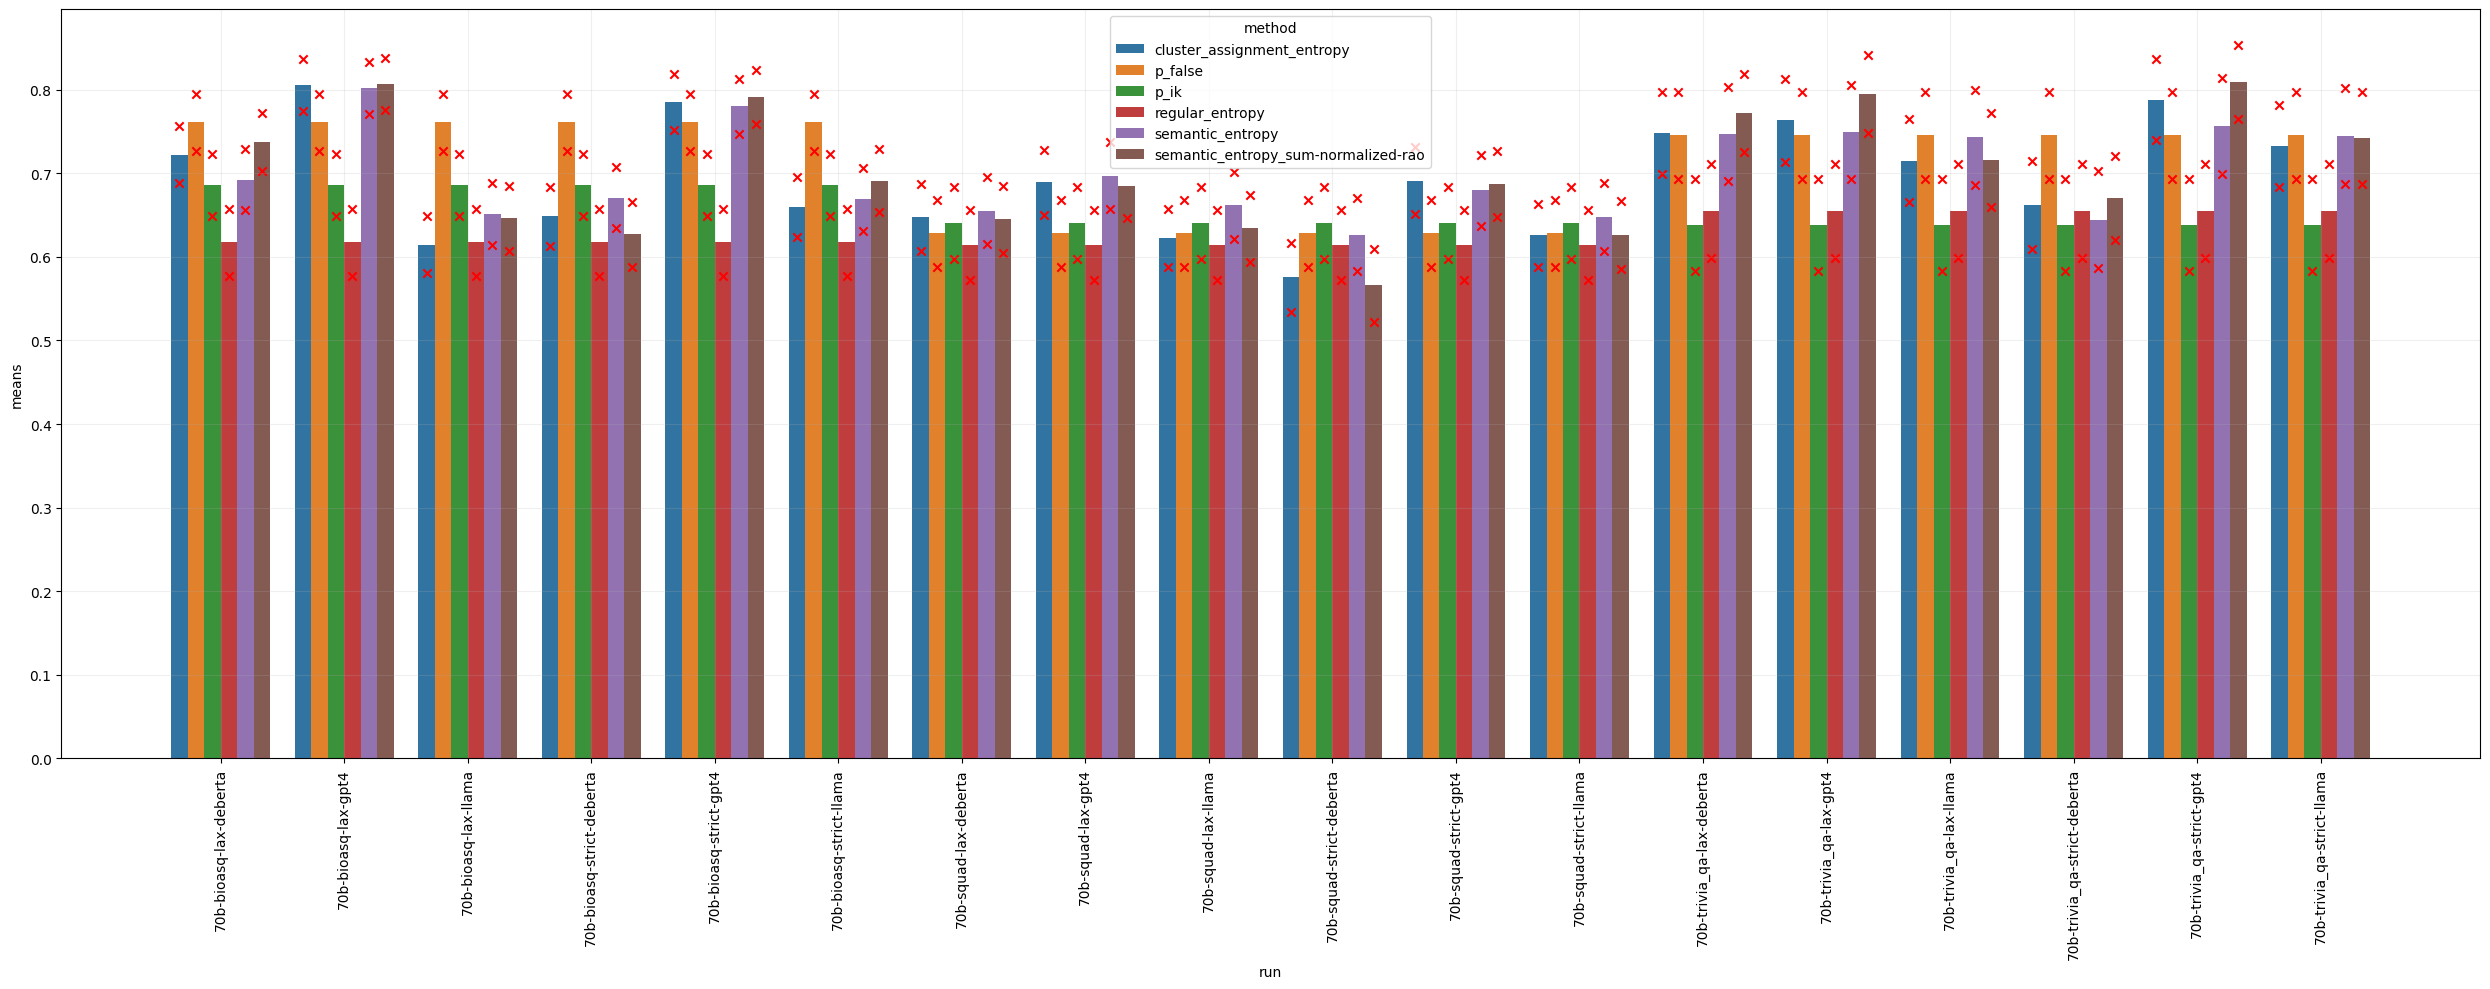

In [84]:
df2 = deepcopy(all_runs)
df2 = df2[df2.metric == 'AUROC']
# df2 = df2[df2.metric == 'area_under_thresholded_accuracy']
main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao']# , 'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao']

df2 = df2[df2.method.map(lambda x: x in main_methods)]
df2 = df2[df2.run.map(lambda x: '70b' in x)]
df2 = df2.sort_values(['method', 'run'])

fig, ax = plt.subplots(1, 1, figsize=(25, 10), sharey=True, dpi=100)

g = sns.barplot(
    x="run",       # x variable name
    y="means",       # y variable name
    hue="method",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.method.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

... maybe a table would be better

In [136]:
all_runs['strictness'] = all_runs.run.map(lambda x: x.split('-')[-2])
all_runs['entailment'] = all_runs.run.map(lambda x: x.split('-')[-1])
all_runs['dataset'] = all_runs.run.map(lambda x: x.split('-')[1])

tmp = all_runs.set_index('metric').loc['AUROC']
tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]
semantic_methods = ['cluster_assignment_entropy', 'semantic_entropy', 'semantic_entropy_sum-normalized-rao']
(tmp.set_index('method').loc[main_methods].reset_index().pivot(columns=['dataset', 'entailment', 'strictness'], index='method', values='means') * 100).style.background_gradient(sns.color_palette('crest', as_cmap=True), axis=None).format(precision=1)


* bioasq
    * lax deberta is better than (strict deberta, lax/strict llama)
    * interestingly: strict is better than lax for llama but not for deberta
* squad
    * lax deberta is better than (strict deberta, lax/strict llama)
    * gpt-4: strict performs almost the same as lax. lax being a tiny bit better for some variants!
    * again: strict llama better than lax llama
* trivia-qa:
    * lax deberta better than strict deberta
    * llama competitive with lax deberta but not better!
    * again strict better than lax
 
Conclusions:

* deberat lax is pretty good
* gpt-4 is better on squad --> check other datasets too

... maybe some averages can help

In [145]:
semantic_methods = ['cluster_assignment_entropy', 'semantic_entropy_sum-normalized-rao']

# average over all datasets and semantic uncertainty methods
tmp2 = tmp.set_index('method').loc[semantic_methods].reset_index().groupby(['entailment', 'strictness', 'method']).mean('means')[['means']].reset_index().pivot(columns=['entailment', 'strictness'], index='method', values='means')
tmp2
(tmp2).style.background_gradient(sns.color_palette('crest', as_cmap=True), axis=None).format(precision=2)

In [17]:
# for each semantic method, I would like to build an auroc table [strictness/entailment]
for semantic_method in semantic_methods:
    print(semantic_method)
    tmp2 = tmp.set_index('method').loc[semantic_method].groupby(['strictness', 'entailment']).mean('means')[['means']]
    display(tmp2)
    best = tmp2.reset_index()[tmp2.reset_index().entailment != 'gpt4'].set_index(['strictness', 'entailment']).idxmax().values
    print('max exlcuding gpt-4', best)

cluster_assignment_entropy


means
strictness entailment          
lax        deberta     0.705908
           gpt4        0.752884
           llama       0.650858
strict     deberta     0.628783
           gpt4        0.755096
           llama       0.672653

max exlcuding gpt-4 [('lax', 'deberta')]
semantic_entropy


means
strictness entailment          
lax        deberta     0.698217
           gpt4        0.749406
           llama       0.685296
strict     deberta     0.647342
           gpt4        0.738802
           llama       0.687030

max exlcuding gpt-4 [('lax', 'deberta')]
semantic_entropy_sum-normalized-rao


means
strictness entailment          
lax        deberta     0.718033
           gpt4        0.762041
           llama       0.665319
strict     deberta     0.621156
           gpt4        0.762720
           llama       0.686455

max exlcuding gpt-4 [('lax', 'deberta')]


# Additional ablation: is gpt35 as good as gpt4 for entailment?

(Unfortunately, this was calculated as part of our num_generations ablation and so, we did this at num_generations = 8)

We could recalculate this for the above data (is just a little annoying, time-consuming! All up to our prioritisation)

Differences

* We also moved to 400 samples for trivia_qa and squad
* And for p_true we now set the maximum number of k-shot to fit within the context

**Update 28/11**: I've recalculated deberta and llama-2 entailment for squad, so that we have complete data there!

I'm also running them for bioaq/trivia_qa

In [92]:

# Additional ablation at 8 generations to check if gpt35 is as good as gpt4
gpt_runs = {
    '37it7nr9': 'trivia_qa-gpt4',
    'mpgj9mz3': 'trivia_qa-gpt3.5',
    'f8yk94fy': 'trivia_qa-deberta',
    'qfwl6vze': 'trivia_qa-llama2',

    '3d6obogq': 'bioasq-gpt4',
    'jj5da8bd': 'bioasq-gpt3.5',
    'lzlhybwt': 'bioasq-deberta',
    '8i0520i0': 'bioasq-llama2',

    '8ehbkd99': 'squad-gpt4',    
    '5bqecpaq': 'squad-gpt3.5',
    'ukagc2et': 'squad-deberta',
    'eriayh79': 'squad-llama2',

    # ignore the gpt4-turbo runs
    # 'rvwyfqfy': 'bioasq-gpt4t',
    # 'ogqt6jkk': 'squad-gpt4t',
    # '64apxuf6': 'trivia_qa-gpt4t',
    
}

gpt_configs, gpt_results = {}, {}

for wandb_id in gpt_runs:
    gpt_results[wandb_id], gpt_configs[wandb_id] = restore_file(wandb_id)

gpt_perfdf, gpt_pdfs, gpt_all_runs = get_perf_df(gpt_runs, gpt_results)
gpt_all_runs['model'] = gpt_all_runs.run.map(lambda x: x.split('-')[1])
gpt_all_runs['dataset'] = gpt_all_runs.run.map(lambda x: x.split('-')[0])

check_first_item(gpt_configs)


model,bioasq,squad,trivia_qa
dataset,,,
deberta,0.545,0.3475,0.8675
gpt3.5,0.545,0.3475,0.8675
gpt4,0.545,0.3475,0.8675
llama2,0.545,0.3475,0.8675


37it7nr9 167218 trivia_qa  Nigel Hawthorne was Oscar nominated for The Madness of which King?
mpgj9mz3 168315 trivia_qa  Nigel Hawthorne was Oscar nominated for The Madness of which King?
f8yk94fy 171337 trivia_qa  Nigel Hawthorne was Oscar nominated for The Madness of which King?
qfwl6vze 171336 trivia_qa  Nigel Hawthorne was Oscar nominated for The Madness of which King?
3d6obogq 167372 bioasq  Computational tools for predicting allosteric pathways in proteins
jj5da8bd 168316 bioasq  Computational tools for predicting allosteric pathways in proteins
lzlhybwt 171335 bioasq  Computational tools for predicting allosteric pathways in proteins
8i0520i0 171334 bioasq  Computational tools for predicting allosteric pathways in proteins
8ehbkd99 167281 squad  What was Warsaw's population in 1901?
5bqecpaq 168317 squad  What was Warsaw's population in 1901?
ukagc2et 171235 squad  What was Warsaw's population in 1901?
eriayh79 171236 squad  What was Warsaw's population in 1901?


In [81]:
pprint(DeepDiff(all_configs['e0z3555u'], gpt_configs['8ehbkd99'], ))

{'dictionary_item_added': [root['p_true_hint'], root['ood_train_dataset'], root['entailment_cache_id'], root['entailment_cache_only'], root['reuse_entailment_model'], root['compute_p_true_in_compute_stage'], root['restore_details_id']],
 'iterable_item_added': {"root['_wandb']['value']['t'][1][4]": 51,
                         "root['_wandb']['value']['t'][1][7]": 71,
                         "root['_wandb']['value']['t'][1][9]": 100,
                         "root['_wandb']['value']['t'][2][4]": 51,
                         "root['_wandb']['value']['t'][2][7]": 71,
                         "root['_wandb']['value']['t'][2][9]": 100},
 'type_changes': {"root['eval_wandb_runid']['value']": {'new_type': <class 'str'>,
                                                        'new_value': 'uvfbxm6d',
                                                        'old_type': <class 'NoneType'>,
                                                        'old_value': None},
                  "root['num_e

Not directly comparable to above runs: data is different and configs are different!

Check diffs for my squad/deberta reruns

In [89]:
pprint(DeepDiff(gpt_configs['eriayh79'], gpt_configs['8ehbkd99']))

{'dictionary_item_added': [root['restore_details_id']],
 'dictionary_item_removed': [root['random_seed'], root['recompute_accuracy']],
 'type_changes': {"root['entailment_cache_id']['value']": {'new_type': <class 'str'>,
                                                           'new_value': 'goatml/semantic_uncertainty/uh7pp7iu',
                                                           'old_type': <class 'NoneType'>,
                                                           'old_value': None}},
 'values_changed': {"root['_wandb']['value']['cli_version']": {'new_value': '0.15.12',
                                                               'old_value': '0.16.0'},
                    "root['_wandb']['value']['huggingface_version']": {'new_value': '4.34.1',
                                                                       'old_value': '4.35.2'},
                    "root['_wandb']['value']['start_time']": {'new_value': 1698863991.944012,
                                       

In [104]:
# check my new llama runs. make sure I did not screw them up
# pprint(DeepDiff(gpt_configs['mpgj9mz3'], gpt_configs['f8yk94fy']))
# pprint(DeepDiff(gpt_configs['mpgj9mz3'], gpt_configs['qfwl6vze']))
# pprint(DeepDiff(gpt_configs['jj5da8bd'], gpt_configs['lzlhybwt']))
# pprint(DeepDiff(gpt_configs['jj5da8bd'], gpt_configs['8i0520i0']))

# pprint(DeepDiff(gpt_configs['lzlhybwt'], gpt_configs['8i0520i0']))

# pprint(DeepDiff(gpt_configs['f8yk94fy'], gpt_configs['lzlhybwt']))

Looks good!

(Note that eval_wandb_runid does not show up correctly for old run due to config bug (that I've since fixed))

/tmp/ipykernel_1855723/135349878.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1855723/135349878.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


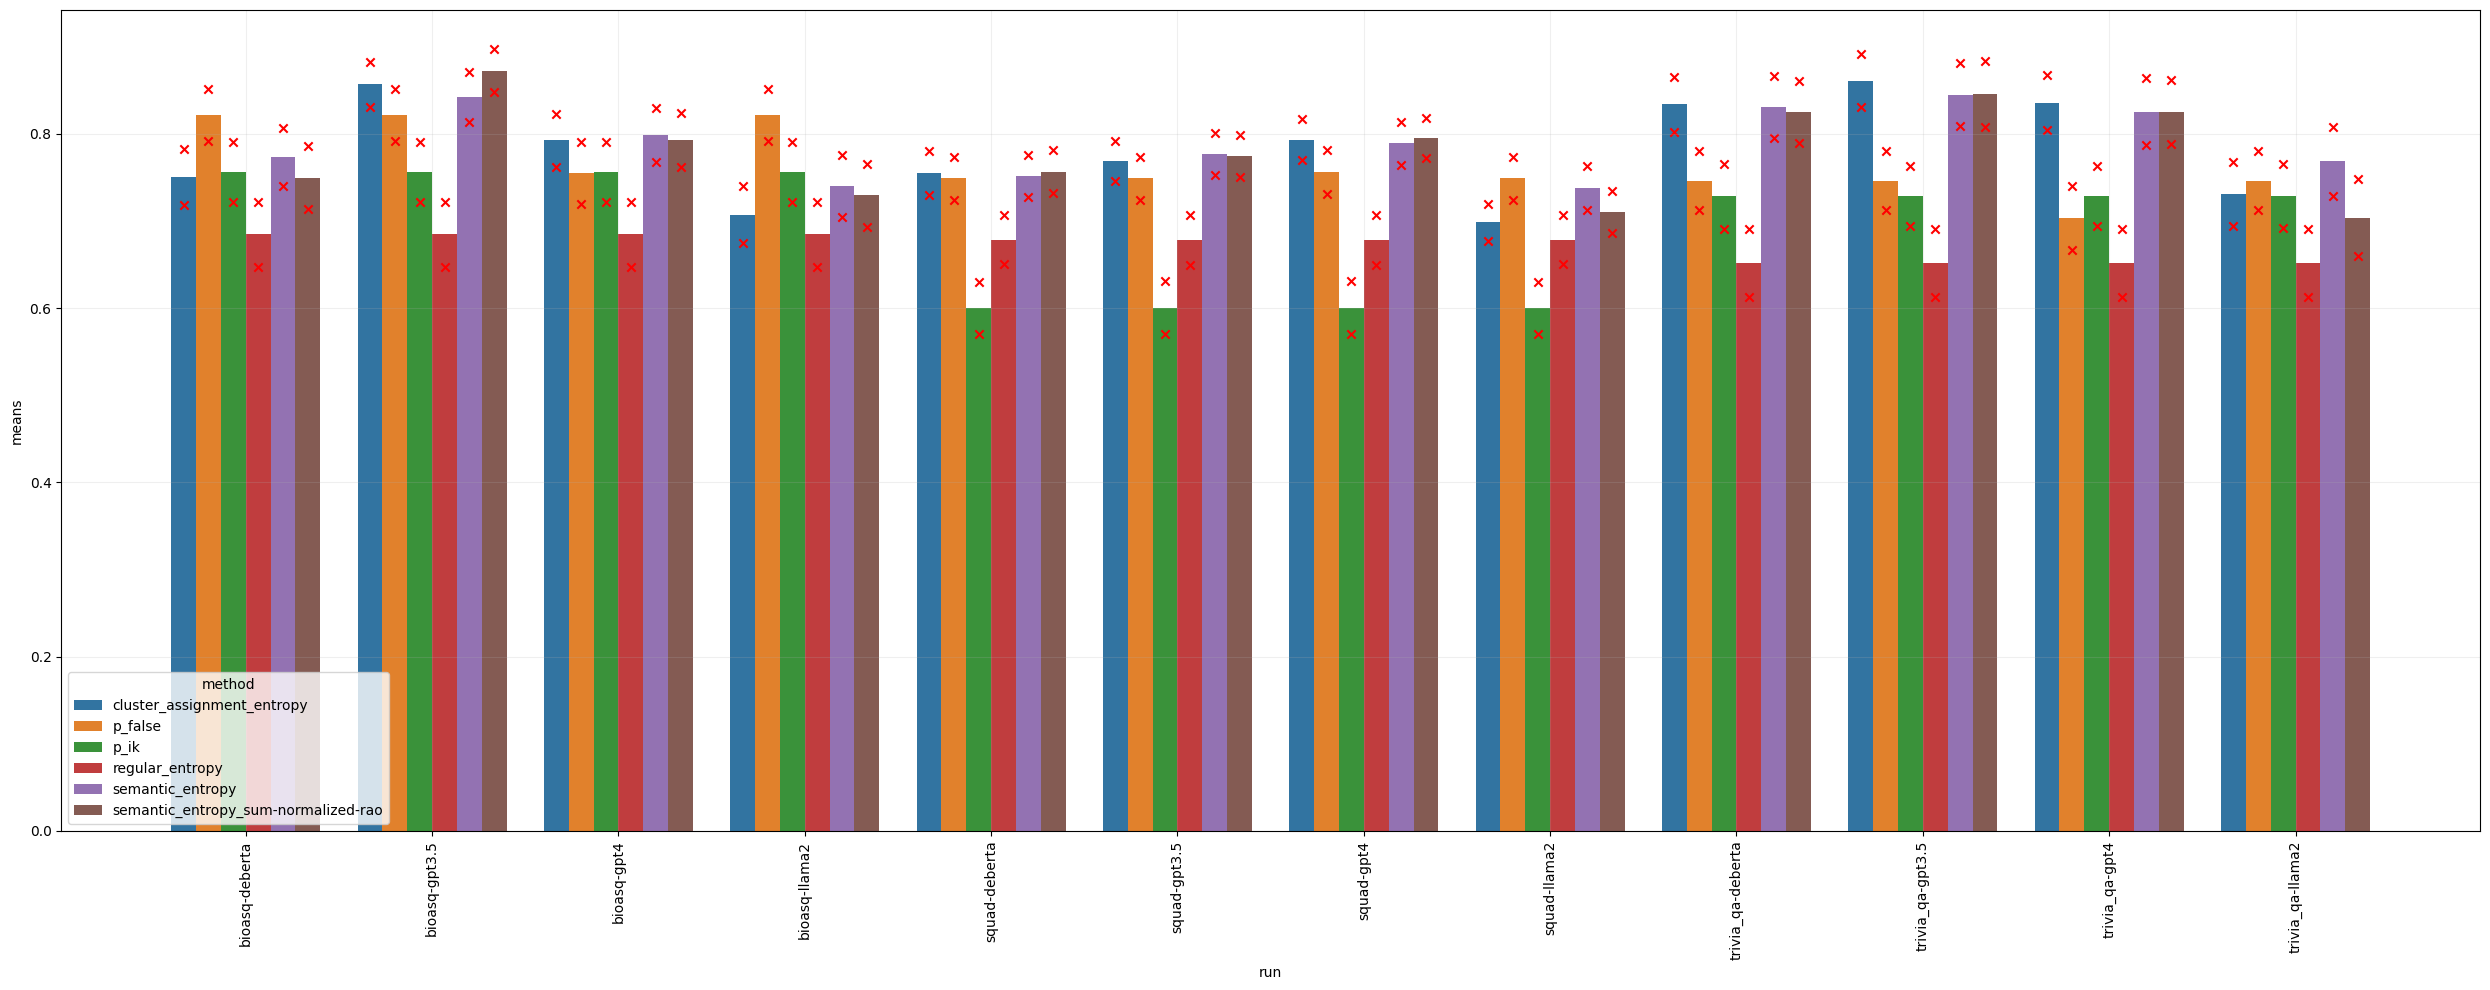

In [105]:
df2 = deepcopy(gpt_all_runs)
df2 = df2[df2.metric == 'AUROC']

df2 = df2[df2.method.map(lambda x: x in main_methods)]
df2 = df2.sort_values(['method', 'run'])

fig, ax = plt.subplots(1, 1, figsize=(25, 10), sharey=True, dpi=100)

g = sns.barplot(
    x="run",       # x variable name
    y="means",       # y variable name
    hue="method",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.method.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

In [146]:
tmp = gpt_all_runs.set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index()
tmp = tmp.groupby(['model', 'method']).mean('means').reset_index().pivot(index='model', columns='method', values='means')
tmp

method,cluster_assignment_entropy,p_false,p_ik,regular_entropy,semantic_entropy,semantic_entropy_sum-normalized-rao
model,,,,,,
deberta,0.779985,0.772620,0.695074,0.671661,0.785162,0.777214
gpt3.5,0.828938,0.772620,0.695164,0.671661,0.821527,0.831266
gpt4,0.807206,0.738392,0.695183,0.671661,0.804421,0.804575
llama2,0.712238,0.772620,0.695183,0.671661,0.748909,0.714738


In [147]:
(tmp * 100).style.background_gradient(sns.color_palette('crest', as_cmap=True), axis=None).format(precision=1)

method,cluster_assignment_entropy,p_false,p_ik,regular_entropy,semantic_entropy,semantic_entropy_sum-normalized-rao
model,,,,,,
deberta,78.0,77.3,69.5,67.2,78.5,77.7
gpt3.5,82.9,77.3,69.5,67.2,82.2,83.1
gpt4,80.7,73.8,69.5,67.2,80.4,80.5
llama2,71.2,77.3,69.5,67.2,74.9,71.5


gpt 35 is a winner in terms of performance!

(or at the very least, is comparable to gpt4)

In [172]:
semantic_methods = ['cluster_assignment_entropy', 'semantic_entropy_sum-normalized-rao']

# average over all datasets and semantic uncertainty methods
tmp = gpt_all_runs.set_index('metric').loc['AUROC'].set_index('method').loc['semantic_entropy_sum-normalized-rao'].reset_index()
tmp['entailment'] = tmp.run.map(lambda x: x.split('-')[-1])
tmp2 = tmp.groupby(['dataset', 'entailment']).mean('means')[['means']].reset_index().pivot(columns=['entailment'], index='dataset', values='means')

tmp2 = tmp2.loc[['trivia_qa', 'squad', 'bioasq']]
tmp2.loc['mean'] = tmp2.mean(0)
tmp2 = tmp2[['deberta', 'llama2', 'gpt3.5', 'gpt4']]


(tmp2).style.background_gradient(sns.color_palette('crest', as_cmap=True), axis=None).format(precision=2)

entailment,deberta,llama2,gpt3.5,gpt4
dataset,,,,
trivia_qa,0.83,0.70,0.85,0.83
squad,0.76,0.71,0.77,0.80
bioasq,0.75,0.73,0.87,0.79
mean,0.78,0.71,0.83,0.80


In [176]:
tmp3 = tmp2.rename(columns={'deberta': 'DeBERTa', 'llama2': 'LLaMa 2 Chat 70B', 'gpt3.5': 'GPT 3.5', 'gpt4': 'GPT-4'}, index={'trivia_qa': 'TriviaQA', 'squad': 'SQuAD', 'bioasq': 'BioASQ', 'mean': 'Average'})
tmp3.index.name = None
tmp3.columns.name = None
tmp3

,DeBERTa,LLaMa 2 Chat 70B,GPT 3.5,GPT-4
TriviaQA,0.825404,0.703986,0.846256,0.825295
SQuAD,0.756567,0.710769,0.774925,0.795557
BioASQ,0.749672,0.729459,0.872618,0.792872
Average,0.777214,0.714738,0.831266,0.804575


In [183]:
tmp3.to_latex()

'\\begin{tabular}{lrrrr}\n\\toprule\n & DeBERTa & LLaMa 2 Chat 70B & GPT 3.5 & GPT-4 \\\\\n\\midrule\nTriviaQA & 0.825404 & 0.703986 & 0.846256 & 0.825295 \\\\\nSQuAD & 0.756567 & 0.710769 & 0.774925 & 0.795557 \\\\\nBioASQ & 0.749672 & 0.729459 & 0.872618 & 0.792872 \\\\\nAverage & 0.777214 & 0.714738 & 0.831266 & 0.804575 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [189]:
print(tmp3.style.format(precision=2).to_latex(hrules=True).replace('Average', '\midrule Average'))

\begin{tabular}{lrrrr}
\toprule
 & DeBERTa & LLaMa 2 Chat 70B & GPT 3.5 & GPT-4 \\
\midrule
TriviaQA & 0.83 & 0.70 & 0.85 & 0.83 \\
SQuAD & 0.76 & 0.71 & 0.77 & 0.80 \\
BioASQ & 0.75 & 0.73 & 0.87 & 0.79 \\
\midrule Average & 0.78 & 0.71 & 0.83 & 0.80 \\
\bottomrule
\end{tabular}

